# 03 — Treino da CNN-B (Refinada)

Rede mais profunda com **data augmentation, BatchNorm, Dropout progressivo e GlobalAveragePooling**. Cada técnica ataca uma limitação do baseline. Meta: **≥ 88% de acurácia no teste**.

> Rodar no **Colab com GPU**. Treino ~8–10 min.

In [1]:
# >>> NO GOOGLE COLAB: rode ESTA célula primeiro (em ambiente local, pule) <<<
# Clona o repositório. NÃO instalamos requirements.txt no Colab: ele já traz
# TensorFlow, Keras, numpy, pandas, scikit-learn, matplotlib, seaborn e
# tensorflow-datasets em versões compatíveis entre si. Reinstalar versões
# fixas rebaixa o ml_dtypes/numpy e quebra o JAX do Colab.
!git clone https://github.com/luanmacea/gs-cnn-eurosat.git
%cd gs-cnn-eurosat

Cloning into 'gs-cnn-eurosat'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 61 (delta 29), reused 41 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 42.36 KiB | 14.12 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/gs-cnn-eurosat


In [2]:
import sys, os
# Resolve a raiz do projeto de forma robusta (local OU Colab, com ou sem
# restart de runtime). Procura uma pasta que contenha 'src/'.
candidatos = [os.getcwd(), os.path.dirname(os.getcwd()), '/content/gs-cnn-eurosat']
ROOT = next((p for p in candidatos if os.path.isdir(os.path.join(p, 'src'))), os.getcwd())
os.chdir(ROOT)  # paths relativos (models/, reports/) consistentes
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print('Project root:', ROOT)

Project root: /content/gs-cnn-eurosat


In [3]:
from src.data_loader import load_raw_data, make_splits, make_tf_datasets, CLASS_NAMES
from src.models import build_cnn_b
from src.train import compile_and_train, save_history
from src.evaluate import plot_training_curves

## Dados (mesma divisão do baseline — seed=42)

In [4]:
images, labels = load_raw_data()
splits = make_splits(images, labels, seed=42)
train_ds, val_ds, test_ds = make_tf_datasets(splits, batch_size=64)

Baixando EuroSAT RGB de: https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://madm.dfki.de/files/sentinel/EuroSAT.zip
  falhou (URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>)
Fonte indisponivel -> _load_from_zip: URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Baixando EuroSAT RGB via Hugging Face (blanchon/EuroSAT_RGB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset carregado: 16200 imagens.


## Arquitetura

In [5]:
model_b = build_cnn_b()
model_b.summary()

Model: "CNN_B_Refined"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,218,378 (4.65 MB)

 Trainable params: 1,216,074 (4.64 MB)

 Non-trainable params: 2,304 (9.00 KB)

Compare a contagem de parâmetros com a CNN-A. O `GlobalAveragePooling2D` substitui o `Flatten`, reduzindo muito a densa final — a CNN-B costuma ter **menos** parâmetros que o baseline, mesmo sendo mais profunda.

## Treino
Além do `EarlyStopping` (patience=10), usamos `ReduceLROnPlateau` para reduzir o learning rate quando a `val_loss` estaciona.

In [6]:
history_b = compile_and_train(
    model_b, train_ds, val_ds,
    epochs=60, lr=1e-3,                          # era 50
    checkpoint_path='models/cnn_b_best.keras',
    patience=12, use_reduce_lr=True,             # era 10
)
save_history(history_b, 'reports/cnn_b_history.json')

Epoch 1/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - accuracy: 0.5672 - loss: 1.3006 - val_accuracy: 0.1128 - val_loss: 5.1042 - learning_rate: 0.0010
Epoch 2/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.6779 - loss: 0.9413 - val_accuracy: 0.1844 - val_loss: 3.9785 - learning_rate: 0.0010
Epoch 3/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.7348 - loss: 0.7723 - val_accuracy: 0.4498 - val_loss: 1.6179 - learning_rate: 0.0010
Epoch 4/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.7533 - loss: 0.7203 - val_accuracy: 0.5650 - val_loss: 1.5445 - learning_rate: 0.0010
Epoch 5/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.7763 - loss: 0.6365 - val_accuracy: 0.6206 - val_loss: 1.3254 - learning_rate: 0.0010
Epoch 6/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.8075 - loss: 0.5771 - val_accuracy: 0.5774 - val_loss: 1.4100 - learning_rate: 0.0010
Epoch 7/60
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.8

## Curvas de aprendizado

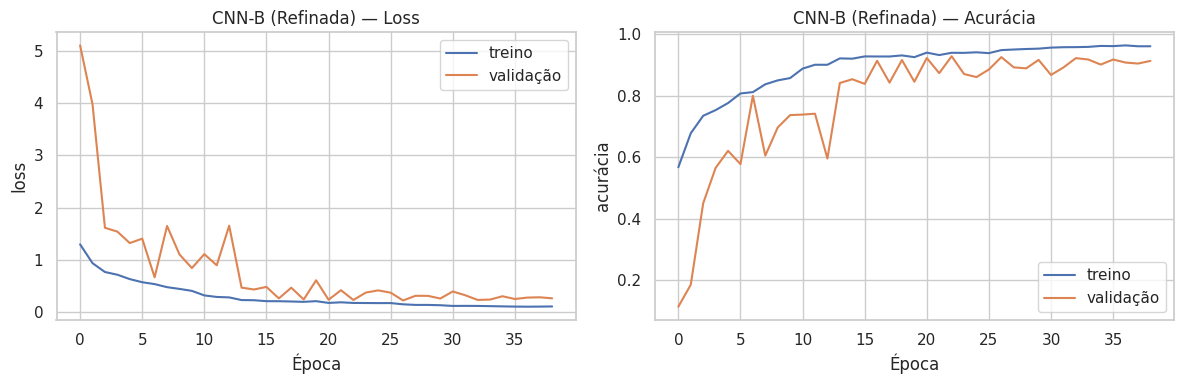

In [7]:
plot_training_curves(history_b.history, title='CNN-B (Refinada)',
                     save_path='reports/figures/cnn_b_curves.png')

## Avaliação no conjunto de teste

In [8]:
test_loss, test_acc = model_b.evaluate(test_ds, verbose=0)
print(f'CNN-B — acurácia no teste: {test_acc:.4f} | loss: {test_loss:.4f}')
print('Meta de 88%:', 'ATINGIDA ✅' if test_acc >= 0.88 else 'NÃO atingida ❌')

CNN-B — acurácia no teste: 0.9128 | loss: 0.2494
Meta de 88%: ATINGIDA ✅


**Se não atingir 88%:** aumente `epochs`, ajuste o `Dropout` (ex.: 0.4 na densa) ou adicione mais um bloco convolucional em `build_cnn_b`. Caso persista, documente a limitação no relatório (o enunciado permite justificativa técnica).